In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import transport.dispersion as dispersion
import transport.orbitcreation as orbitcreation
import transport.conductivity as conductivity
from transport.makesigmalist import makelist_parallel
from time import time

# 22 percent sample

In [2]:
thetalist = np.linspace(-14,99,80)

res_z = 20
res_xy = 100

fixedparams = [190e-3,-0.134,0.067,0.805] #T,T1multvalue,T11multvalue,mumultvalue

def create_rhozz(phi,Bmag,params):
    dispersionInstance = dispersion.LSCOdispersion(T=fixedparams[0],T1multvalue=fixedparams[1],T11multvalue=fixedparams[2],Tzmultvalue=params[0],mumultvalue=fixedparams[3])

    #0.22 params
    #T= 190e-3,T1multvalue=-0.134,T11multvalue=0.067,Tzmultvalue=Tzmultvalue,mumultvalue=0.805

    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    starttime = time()
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    calculated_doping = FSorbitsInstance.calculateDoping()
    endtime = time()
    print(f"Time taken to create Fermi Surface = {endtime - starttime}. Doping = {calculated_doping}%")

    def create_rhozz(phi,Bmag):
        phi_rad = np.deg2rad(phi)

        conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=params[1],invtau_aniso=params[2])
        starttime = time()
        conductivityInstance.createAmatrix_Bindependent()
        endtime = time()
        print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

        def getsigma(theta):
            B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
            conductivityInstance.createAmatrix_Bdependent(B)
            conductivityInstance.createAlpha()
            conductivityInstance.createSigma()

            #print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
            return conductivityInstance.sigma,conductivityInstance.areasum

        sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist)
        rhozzlist= [rho[2,2]*10e-5 for rho in rholist]

        return rhozzlist
    
    rhozzlist = create_rhozz(phi=phi,Bmag=Bmag)

    return rhozzlist

In [ ]:
Tlist = [20,25,30,35]
paramslist = []

for temp in Tlist:
    filename = f"fit_logs_fixTz_at35K/fit_logs_22perc_{temp}K.txt"
    cost,Tzmultvalue,invtau_iso,invtau_aniso = np.loadtxt(filename,unpack=True,skiprows=5,delimiter=",")
    min_index = np.argmin(cost)
    paramslist.append((Tzmultvalue[min_index],invtau_iso[min_index],invtau_aniso[min_index]))
    print((Tzmultvalue[min_index],invtau_iso[min_index],invtau_aniso[min_index]))

rhozzlist0 = []
rhozzlist45 = []
data_rhozz0list = []
data_rhozz45list = []
data_theta0list = []
data_theta45list = []

for T,params in zip(Tlist,paramslist):

    #load data
    data_theta0,data_rhozz0 = np.loadtxt(f"data/admr_data/2601C/2601C_phi0_T{T}K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta0list.append(data_theta0)
    data_rhozz0list.append(data_rhozz0)

    data_theta45,data_rhozz45 = np.loadtxt(f"data/admr_data/2601C/2601C_phi45_T{T}K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta45list.append(data_theta45)
    data_rhozz45list.append(data_rhozz45)

    #generate data
    rhozzlist0.append(create_rhozz(phi=0,Bmag=45,params=params))
    rhozzlist45.append(create_rhozz(phi=45,Bmag=45,params=params))

(np.float64(0.07941809516397977), np.float64(9.987011274570893), np.float64(180.12794464321343))
(np.float64(0.07941809516397977), np.float64(11.63986687095777), np.float64(181.39081265472686))
(np.float64(0.07941809516397977), np.float64(12.952701443010504), np.float64(185.0321744046277))
(np.float64(0.07941839419796835), np.float64(14.043939769588011), np.float64(189.85486969743133))
Time taken to create Fermi Surface = 0.07880187034606934. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.6485018730163574
Time taken to create Fermi Surface = 0.06347823143005371. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.004694223403930664
Time taken to create Fermi Surface = 0.0632176399230957. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.00543975830078125
Time taken to create Fermi Surface = 0.0629115104675293. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.0043811798095703125
Tim

<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:8: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not w

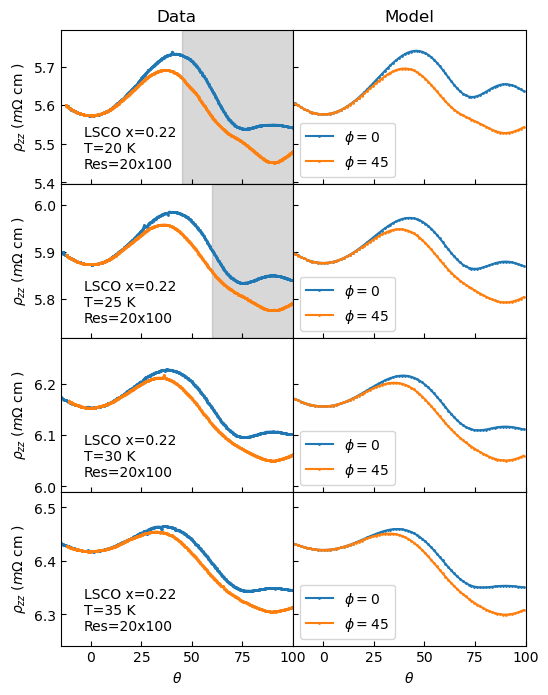

In [4]:
fig,axes = plt.subplots(nrows=4,ncols=2,figsize=(6,8),sharex=True)

for T,row,params,data_theta0,data_theta45,data_rhozz0,data_rhozz45,rhozz0,rhozz45 in zip(Tlist,axes,paramslist,data_theta0list,data_theta45list,data_rhozz0list,data_rhozz45list,rhozzlist0,rhozzlist45):

    row[1].plot(thetalist,rhozz0,ls="-",marker="o",ms=1,label=f"$\phi=0$")
    row[1].plot(thetalist,rhozz45,ls="-",marker="o",ms=1,label=f"$\phi=45$")
    row[0].plot(data_theta0,data_rhozz0,ls="-",marker="o",ms=1,label=f"$\phi=0$")
    row[0].plot(data_theta45,data_rhozz45,ls="-",marker="o",ms=1,label=f"$\phi=45$")
    row[0].set_ylabel(r"$\rho_{zz}$ ($m\Omega$ cm )")
    row[0].text(0.1,0.1,f"LSCO x=0.22\nT={T} K\nRes={res_z}x{res_xy}",fontsize=10, transform=row[0].transAxes)
    row[1].legend()
    row[1].set_yticklabels([])

    for column in row:
        column.set_ylim(np.min(data_rhozz45)*0.99,np.max(data_rhozz0)*1.01)
        column.tick_params(direction='in')

axes[3,0].set_xlabel(r'$\theta$')
axes[3,1].set_xlabel(r'$\theta$')
axes[0,0].set_title("Data")
axes[0,1].set_title("Model")

axes[0,0].axvspan(45, 120, alpha=0.3, color='gray')
axes[1,0].axvspan(60, 120, alpha=0.3, color='gray')
axes[0,0].set_xlim(-15,100)

#make vspace 0
plt.subplots_adjust(hspace=0.0,wspace=0.0)

plt.show()

In [ ]:
data_theta15list = []
data_rhozz15list = []

data_theta30list = []
data_rhozz30list = []

rhozzlist15 = []
rhozzlist30 = []

for T,params in zip(Tlist,paramslist):

    #load data
    data_theta15,data_rhozz15 = np.loadtxt(f"data/admr_data/2601C/2601C_phi15_T{T}K_B41.5T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta15list.append(data_theta15)
    data_rhozz15list.append(data_rhozz15)

    data_theta30,data_rhozz30 = np.loadtxt(f"data/admr_data/2601C/2601C_phi30_T{T}K_B41.5T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta30list.append(data_theta30)
    data_rhozz30list.append(data_rhozz30)

    #generate data
    rhozzlist15.append(create_rhozz(phi=15,Bmag=41.5,params=params))
    rhozzlist30.append(create_rhozz(phi=30,Bmag=41.5,params=params))

Time taken to create Fermi Surface = 0.06451845169067383. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.007497549057006836
Time taken to create Fermi Surface = 0.0660398006439209. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.00501561164855957
Time taken to create Fermi Surface = 0.06768226623535156. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.004896402359008789
Time taken to create Fermi Surface = 0.0683138370513916. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.005986452102661133
Time taken to create Fermi Surface = 0.0675668716430664. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.004328727722167969
Time taken to create Fermi Surface = 0.0637810230255127. Doping = 0.233285756099596%
Time taken to create B independent Amatrix =  0.00421452522277832
Time taken to create Fermi Surface = 0.06360912322998047. Doping = 0.23328578657658017%


<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:8: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not w

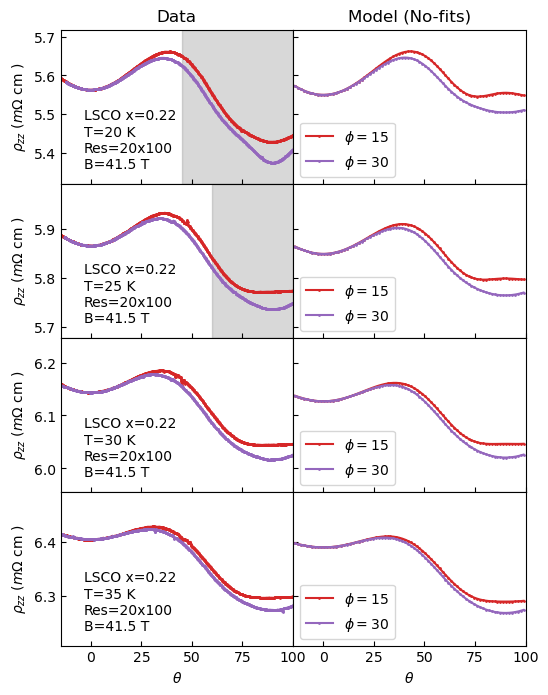

In [6]:
fig,axes = plt.subplots(nrows=4,ncols=2,figsize=(6,8),sharex=True)

for T,row,params,data_theta15,data_theta30,data_rhozz15,data_rhozz30,rhozz15,rhozz30 in zip(Tlist,axes,paramslist,data_theta15list,data_theta30list,data_rhozz15list,data_rhozz30list,rhozzlist15,rhozzlist30):

    row[1].plot(thetalist,rhozz15,ls="-",marker="o",ms=1,label=f"$\phi=15$",color="C3")
    row[1].plot(thetalist,rhozz30,ls="-",marker="o",ms=1,label=f"$\phi=30$",color="C4")
    row[0].plot(data_theta15,data_rhozz15,ls="-",marker="o",ms=1,label=f"$\phi=15$",color="C3")
    row[0].plot(data_theta30,data_rhozz30,ls="-",marker="o",ms=1,label=f"$\phi=30$",color="C4")
    row[0].set_ylabel(r"$\rho_{zz}$ ($m\Omega$ cm )")
    row[0].text(0.1,0.1,f"LSCO x=0.22\nT={T} K\nRes={res_z}x{res_xy}\nB=41.5 T",fontsize=10, transform=row[0].transAxes)
    row[1].legend()
    row[1].set_yticklabels([])

    for column in row:
        column.set_ylim(np.min(data_rhozz30)*0.99,np.max(data_rhozz15)*1.01)
        column.tick_params(direction='in')

axes[3,0].set_xlabel(r'$\theta$')
axes[3,1].set_xlabel(r'$\theta$')
axes[0,0].set_title("Data")
axes[0,1].set_title("Model (No-fits)")

axes[0,0].axvspan(45, 120, alpha=0.3, color='gray')
axes[1,0].axvspan(60, 120, alpha=0.3, color='gray')
axes[0,0].set_xlim(-15,100)

#make vspace 0
plt.subplots_adjust(hspace=0.0,wspace=0.0)

plt.show()